In [1]:
from pathlib import Path
from ase.io import read
from ase import Atoms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def map_zno_bands(band_array):
    """
    Mapeia um array (X, 12) para os modos específicos do ZnO.
    Assume que as bandas estão em ordem crescente de energia.
    """
    return {
        "Acusticos": band_array[:, 0:3],   # Transversal e Longitudinal Acústico
        "E2_low":    band_array[:, 3:5],   # Vibração Zn (Plano xy)
        "B1_low":    band_array[:, 5],     # Silencioso (Eixo z)
        "TO_modes":  band_array[:, 6:8],   # E1(TO) e A1(TO)
        "B1_high":   band_array[:, 8],     # Silencioso (Eixo z)
        "E2_high":   band_array[:, 9:11],  # Vibração O (Plano xy)
        "LO_top":    band_array[:, 11]     # Geralmente A1(LO)
    }


def plot_in_ax(x, y, ax, **kwargs):
    """Plot in a specified ax with optional keyword arguments color and linestyle"""
    

    ax.plot(x, y, **kwargs)



def get_high_symmetry_points_and_labes(filename: str):
    """Lê o arquivo .bands do alamode

    Returns:
        - labels1 : list[str]   com pontos de alta simetria -> xtick labels
        - pontos  : list[float] com pontos de alta simetria -> xticks  
        
    """
    with open(filename, "r") as f:
        lines: list[str] = f.readlines()

    labels: list[str] = lines[0].strip().split()[1:]
    xticklabels = [r"$\Gamma$" if label == "G" else label for label in labels]

    xticks = np.array(lines[1].strip().split()[1:], dtype=float)    

    return xticklabels, xticks

In [3]:
path_dft = "/home/jvc/ZnO_database/alamode_phonons/01_qe_finite_diff/LDA/bandas_backup/zno222_NA0.bands"
path_mlff = "/home/jvc/ZnO_database/alamode_phonons/03_mlff_aenetpytorch/LDA/model006/phonons/zno_lda_mlff.bands"

dft_data = np.loadtxt(path_dft,comments="#" )
mlff_data = np.loadtxt(path_mlff, comments="#")

x_dft = dft_data[:, 0]
bandas_dft = dft_data[:, 1:]

x_mlff = mlff_data[:, 0]
bandas_mlff = mlff_data[:, 1:]

dft_modes = map_zno_bands(bandas_dft)
mlff_modes = map_zno_bands(bandas_mlff)


xticklabels, xticks = get_high_symmetry_points_and_labes(path_dft) # They share the same

In [4]:
def plot_panel_comparing_modes(kpoints: np.ndarray, bandas_dft: np.ndarray, bandas_mlff: np.ndarray, save=False, **kwargs):
    """
    Plotar individualmente as 12 bandas do Óxido de Zinco.
    """
    style_DFT = dict(color="black", ls='-', lw=2, label="DFT")
    style_MLFF = dict(color="red", ls="--", lw=2, label="MLFF")
    
    fig, axes = plt.subplots(figsize=(14,14),nrows=4, ncols=3, dpi=300, layout="constrained")
    fig.set_facecolor("#f4f4f4")
    fig.suptitle("Normal Modes of Zinc Oxide", fontsize=18)
    
    
    
    mode_names = [
        r"TA$_1$", r"TA$_2$", r"LA",
        r"E$_2^{\mathrm{low}}$ (1)", r"E$_2^{\mathrm{low}}$ (2)", r"B$_1^{\mathrm{low}}$",
        r"A$_1$", r"E$_1$ (1)", r"E$_1$ (2)",
        r"E$_2^{\mathrm{high}}$ (1)", r"E$_2^{\mathrm{high}}$ (2)", r"B$_1^{\mathrm{high}}$"
    ]

    # Assuming 'axes' is your flattened 1D array of the 12 subplots
    for i, ax in enumerate(axes.flatten()):
        if i in (0, 3, 6, 9, 12):
                ax.set_ylabel(r"Frequency cm$^{-1}$", size=14)
        
        ax.set_title(mode_names[i], fontsize=12, loc='left')
        ax.plot(kpoints, bandas_dft[:, i], **style_DFT)
        ax.plot(kpoints, bandas_mlff[:, i], **style_MLFF)
        ax.legend()
        ax.tick_params(direction="inout")

    
        for spine in ['left', 'right', 'top', 'bottom']:
            ax.spines[spine].set_linewidth(1.5)
        
        if kwargs is not None:
             ax.set_xticks(kwargs['xticks'])
             ax.set_xticklabels(kwargs['xticklabels'], size=12)

             for vline in kwargs['xticks']:
                  ax.axvline(vline, ls='--', color='gray', alpha=0.3, lw=0.5)
    
    if save:
         filename = input("Digite o nome do plot:\n")
         plt.savefig(filename)
    
    plt.show()
    return ax 

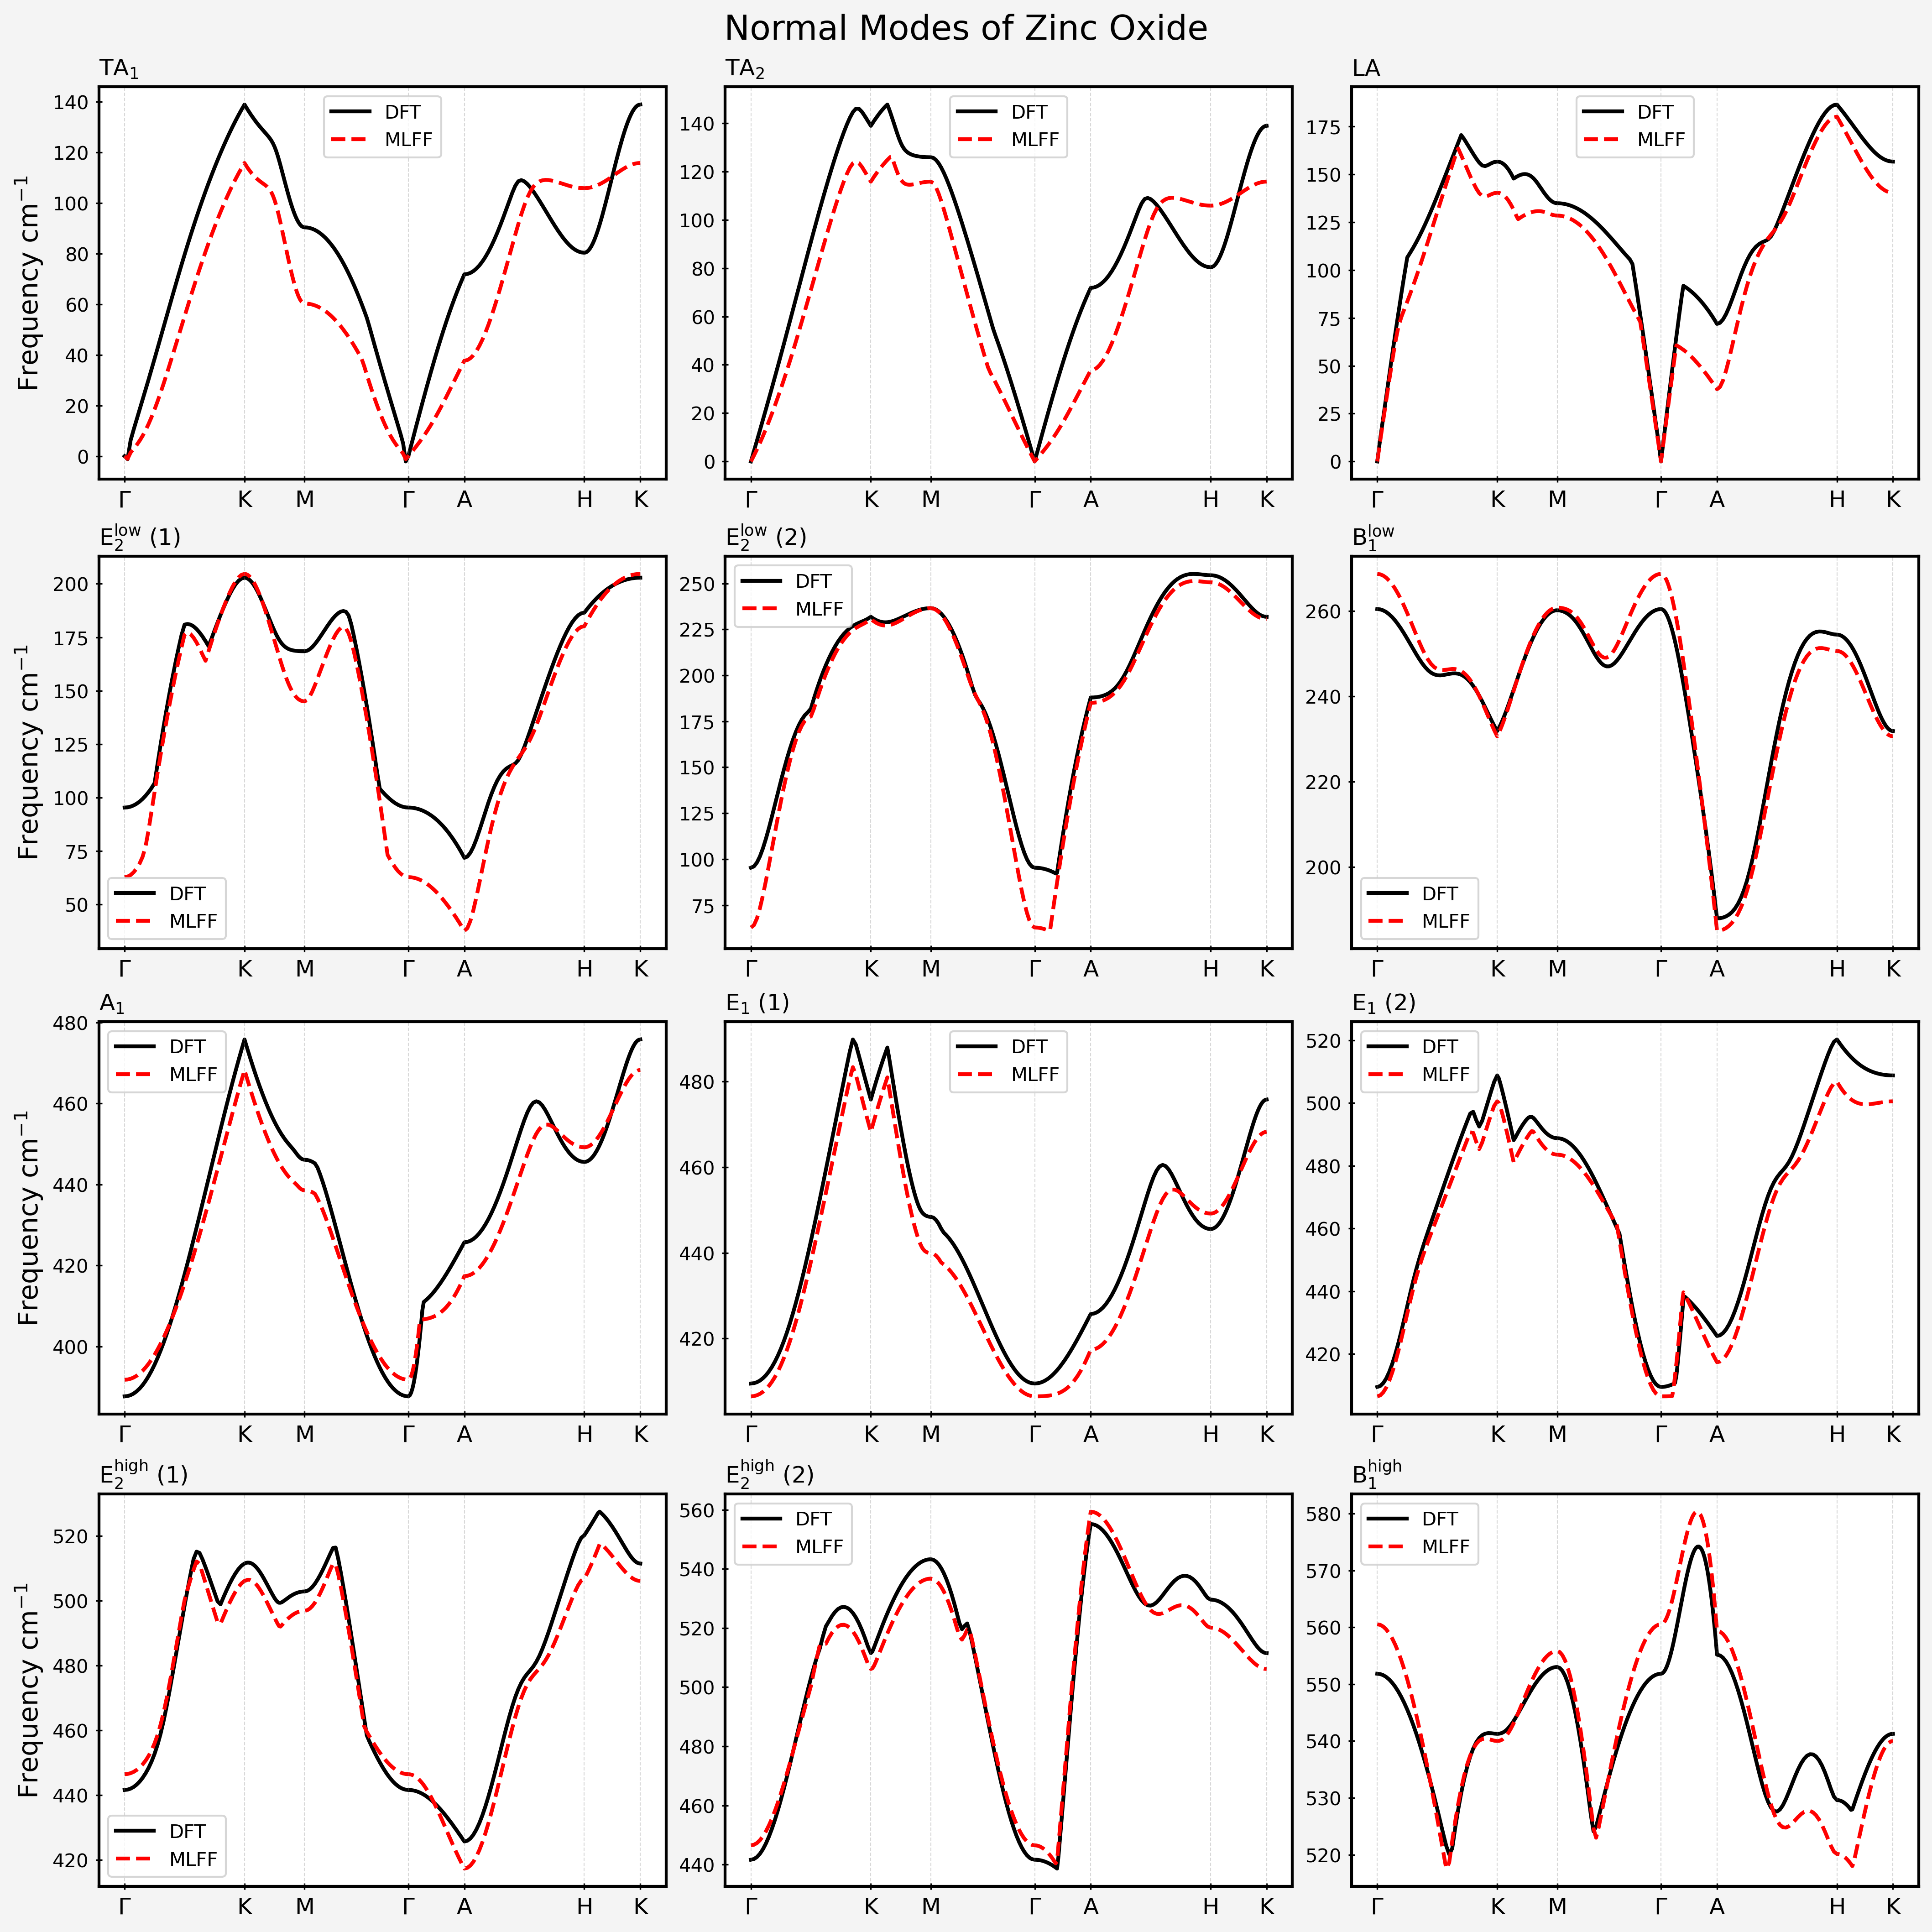

<Axes: title={'left': 'B$_1^{\\mathrm{high}}$'}>

In [5]:
plot_panel_comparing_modes(kpoints=x_dft, bandas_dft=bandas_dft, bandas_mlff=bandas_mlff, save=True, xticks=xticks, xticklabels=xticklabels)